# DoubleML Tutorial 05: Interactive Regression Model IRM

This notebook is a full tutorial on `DoubleMLIRM`, the interactive regression model for binary treatments.

The previous notebooks handled continuous treatments. Here the treatment is binary: a unit either receives the intervention or does not. That changes the estimand, the nuisance functions, and the diagnostics. Instead of residualizing a continuous treatment, IRM combines outcome regressions and a propensity score to estimate ATE and ATTE-style targets.

The goal is to understand the full workflow: potential-outcome estimands, identification assumptions, propensity overlap, manual AIPW estimation, DoubleML fitting, nuisance diagnostics, and honest reporting.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain the IRM setup for binary treatments.
- Define ATE and ATTE in potential-outcome notation.
- State the identification assumptions: consistency, unconfoundedness, overlap, and no interference.
- Explain the roles of `ml_g` and `ml_m` in `DoubleMLIRM`.
- Manually compute cross-fitted AIPW estimates for ATE and ATT-style targets.
- Fit `DoubleMLIRM` for `score="ATE"` and `score="ATTE"`.
- Diagnose propensity overlap, inverse-propensity weights, nuisance losses, and score contributions.
- Understand how weak overlap can inflate uncertainty.

## Binary Treatments And Potential Outcomes

For a binary treatment, each unit has two potential outcomes:

$$
Y(1) \quad \text{and} \quad Y(0).
$$

`Y(1)` is the outcome the unit would have under treatment. `Y(0)` is the outcome the same unit would have without treatment. We observe only one of them:

$$
Y = D Y(1) + (1-D)Y(0),
$$

where `D = 1` means treated and `D = 0` means untreated.

Two common targets are:

$$
ATE = E[Y(1) - Y(0)]
$$

and

$$
ATT = E[Y(1) - Y(0) \mid D=1].
$$

DoubleML names the treated-target score `ATTE`. In this notebook we use `ATTE` when referring to the DoubleML score option and ATT-style language when explaining the estimand.

## Identification Assumptions

IRM is not an instrument or randomized experiment by itself. It estimates causal effects from observational data under assumptions.

The standard observed-control identification assumptions are:

- Consistency: the observed outcome equals the potential outcome under the treatment actually received.
- Conditional unconfoundedness: after controlling for `X`, treatment assignment is independent of potential outcomes.
- Overlap or positivity: every covariate profile has a nonzero probability of receiving each treatment state.
- No interference: one unit's treatment does not change another unit's potential outcomes.

DoubleML helps with flexible nuisance estimation and orthogonal scores. It does not make these assumptions true.

## IRM Nuisance Functions

`DoubleMLIRM` uses two main nuisance components:

$$
g_0(0, X) = E[Y \mid D=0, X]
$$

$$
g_0(1, X) = E[Y \mid D=1, X]
$$

and

$$
m_0(X) = P(D=1 \mid X).
$$

In the API:

- `ml_g` estimates the outcome regression. DoubleML internally learns both treated and untreated outcome predictions.
- `ml_m` estimates the propensity score, so it must be a classifier with `predict_proba()`.

This is different from PLR and PLIV. In IRM, the treatment is binary and the propensity score is central.

## The AIPW Score For ATE

The ATE score combines regression adjustment and inverse-propensity weighting:

$$
\psi_i = \hat g_1(X_i) - \hat g_0(X_i)
+ \frac{D_i(Y_i - \hat g_1(X_i))}{\hat m(X_i)}
- \frac{(1-D_i)(Y_i - \hat g_0(X_i))}{1-\hat m(X_i)}.
$$

The estimate is the average of this score. This is often called an augmented inverse-propensity weighted estimator.

The score is doubly robust in the usual sense: under suitable conditions, the estimate can remain consistent if either the propensity model or the outcome model is correctly specified. DoubleML adds cross-fitting and orthogonalization to make flexible machine-learning nuisance estimation more reliable.

## Runtime Note

This notebook fits cross-fitted binary-treatment models, two DoubleML scores, and a repeated-splitting check. On a typical laptop, the full notebook should take roughly two to four minutes.

The examples use a synthetic dataset large enough to show overlap and heterogeneity, but small enough to rerun comfortably.

## Setup

This cell prepares the notebook environment. It creates output folders, makes matplotlib cache writes local to the tutorial folder, imports scientific Python libraries, and records package versions.

The path logic supports running from the repository root or directly from the tutorial folder.

In [1]:
from pathlib import Path
import os
import warnings

NOTEBOOK_PREFIX = "05"
RANDOM_STATE = 2026

CURRENT_DIR = Path.cwd().resolve()
if CURRENT_DIR.name == "doubleml":
    REPO_ROOT = CURRENT_DIR.parents[2]
elif (CURRENT_DIR / "notebooks" / "tutorials" / "doubleml").exists():
    REPO_ROOT = CURRENT_DIR
else:
    REPO_ROOT = CURRENT_DIR

OUTPUT_DIR = REPO_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LassoCV, LinearRegression, LogisticRegressionCV
from sklearn.metrics import log_loss, mean_absolute_error, mean_squared_error, roc_auc_score, r2_score
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm

import doubleml as dml
from doubleml import DoubleMLData, DoubleMLIRM

warnings.filterwarnings("ignore", category=ConvergenceWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

package_versions = pd.DataFrame(
    [
        {"package": "doubleml", "version": dml.__version__},
        {"package": "numpy", "version": np.__version__},
        {"package": "pandas", "version": pd.__version__},
        {"package": "seaborn", "version": sns.__version__},
        {"package": "statsmodels", "version": sm.__version__},
    ]
)
package_versions.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(package_versions)

,package,version
0,doubleml,0.11.2
1,numpy,2.4.4
2,pandas,3.0.2
3,seaborn,0.13.2
4,statsmodels,0.14.6


The package versions are part of the reproducibility record. Cross-fitting, tree learners, and classifier calibration can shift slightly across package versions.

## Helper Functions

The helper functions below keep the analysis cells focused on the causal workflow.

They handle table saving, sigmoid transformation, baseline summaries, AIPW calculations, cross-fitted nuisance predictions, effective sample size, and DoubleML prediction extraction.

In [2]:
def save_table(df, name):
    path = TABLE_DIR / f"{NOTEBOOK_PREFIX}_{name}.csv"
    df.to_csv(path, index=False)
    return df


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def treatment_ols_summary(y, X, treatment_col, label):
    X_design = sm.add_constant(X, has_constant="add")
    fit = sm.OLS(y, X_design).fit(cov_type="HC1")
    row = fit.summary2().tables[1].loc[treatment_col]
    return {
        "estimator": label,
        "target": "raw regression slope",
        "theta_hat": float(row["Coef."]),
        "std_error": float(row["Std.Err."]),
        "ci_95_lower": float(row["[0.025"]),
        "ci_95_upper": float(row["0.975]"]),
        "p_value": float(row["P>|z|"]),
    }


def mean_difference_summary(y, d, label):
    treated = y[d == 1]
    untreated = y[d == 0]
    theta_hat = float(treated.mean() - untreated.mean())
    std_error = float(np.sqrt(treated.var(ddof=1) / len(treated) + untreated.var(ddof=1) / len(untreated)))
    return {
        "estimator": label,
        "target": "unadjusted mean difference",
        "theta_hat": theta_hat,
        "std_error": std_error,
        "ci_95_lower": theta_hat - 1.96 * std_error,
        "ci_95_upper": theta_hat + 1.96 * std_error,
        "p_value": np.nan,
    }


def aipw_ate(y, d, g0_hat, g1_hat, m_hat, label):
    m_hat = np.clip(np.asarray(m_hat), 0.02, 0.98)
    score = g1_hat - g0_hat + d * (y - g1_hat) / m_hat - (1 - d) * (y - g0_hat) / (1 - m_hat)
    theta_hat = float(np.mean(score))
    std_error = float(np.std(score, ddof=1) / np.sqrt(len(score)))
    return {
        "estimator": label,
        "target": "ATE",
        "theta_hat": theta_hat,
        "std_error": std_error,
        "ci_95_lower": theta_hat - 1.96 * std_error,
        "ci_95_upper": theta_hat + 1.96 * std_error,
        "p_value": np.nan,
    }


def aipw_att(y, d, g0_hat, m_hat, label):
    m_hat = np.clip(np.asarray(m_hat), 0.02, 0.98)
    p_treated = float(np.mean(d))
    score = d * (y - g0_hat) / p_treated - (1 - d) * m_hat * (y - g0_hat) / ((1 - m_hat) * p_treated)
    theta_hat = float(np.mean(score))
    std_error = float(np.std(score, ddof=1) / np.sqrt(len(score)))
    return {
        "estimator": label,
        "target": "ATT-style",
        "theta_hat": theta_hat,
        "std_error": std_error,
        "ci_95_lower": theta_hat - 1.96 * std_error,
        "ci_95_upper": theta_hat + 1.96 * std_error,
        "p_value": np.nan,
    }


def ipw_ate(y, d, m_hat, label):
    m_hat = np.clip(np.asarray(m_hat), 0.02, 0.98)
    score = d * y / m_hat - (1 - d) * y / (1 - m_hat)
    theta_hat = float(np.mean(score))
    std_error = float(np.std(score, ddof=1) / np.sqrt(len(score)))
    return {
        "estimator": label,
        "target": "ATE",
        "theta_hat": theta_hat,
        "std_error": std_error,
        "ci_95_lower": theta_hat - 1.96 * std_error,
        "ci_95_upper": theta_hat + 1.96 * std_error,
        "p_value": np.nan,
    }


def weighted_effective_sample_size(weights):
    weights = np.asarray(weights)
    return float((weights.sum() ** 2) / np.sum(weights ** 2))


def crossfit_irm_nuisances(X, y, d, outcome_learner, propensity_learner, n_splits=5, random_state=RANDOM_STATE):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    g0_hat = np.zeros(len(y))
    g1_hat = np.zeros(len(y))
    m_hat = np.zeros(len(y))

    for train_idx, test_idx in cv.split(X):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y[train_idx]
        d_train = d[train_idx]

        g0_model = clone(outcome_learner).fit(X_train[d_train == 0], y_train[d_train == 0])
        g1_model = clone(outcome_learner).fit(X_train[d_train == 1], y_train[d_train == 1])
        m_model = clone(propensity_learner).fit(X_train, d_train)

        g0_hat[test_idx] = g0_model.predict(X_test)
        g1_hat[test_idx] = g1_model.predict(X_test)
        m_hat[test_idx] = m_model.predict_proba(X_test)[:, 1]

    return g0_hat, g1_hat, np.clip(m_hat, 0.02, 0.98)


def prediction_vector(doubleml_model, learner_key):
    arr = np.asarray(doubleml_model.predictions[learner_key])
    if arr.ndim != 3:
        raise ValueError(f"Expected a 3D prediction array, got shape {arr.shape}")
    return arr[:, 0, 0]


def learner_loss_table(doubleml_model, model_label):
    losses = doubleml_model.evaluate_learners()
    rows = []
    for learner_name, values in losses.items():
        arr = np.asarray(values)
        rows.append(
            {
                "model": model_label,
                "learner": learner_name,
                "mean_loss": float(np.mean(arr)),
                "min_loss": float(np.min(arr)),
                "max_loss": float(np.max(arr)),
            }
        )
    return pd.DataFrame(rows)

The manual AIPW formulas are included so the notebook does not feel like magic. DoubleML automates these ideas with careful score construction, sample splitting, repeated splitting, bootstrap tools, and consistent model objects.

## Draw The IRM Design

The diagram below shows the observed-control design.

Observed covariates `X` affect both treatment assignment and potential outcomes. The binary treatment `D` affects the observed outcome `Y`. Under unconfoundedness, adjusting for `X` is enough to compare treated and untreated potential outcomes.

The dashed box reminds us that unobserved confounding is a design threat. If a hidden variable affects both treatment and outcome after conditioning on `X`, IRM is not enough.

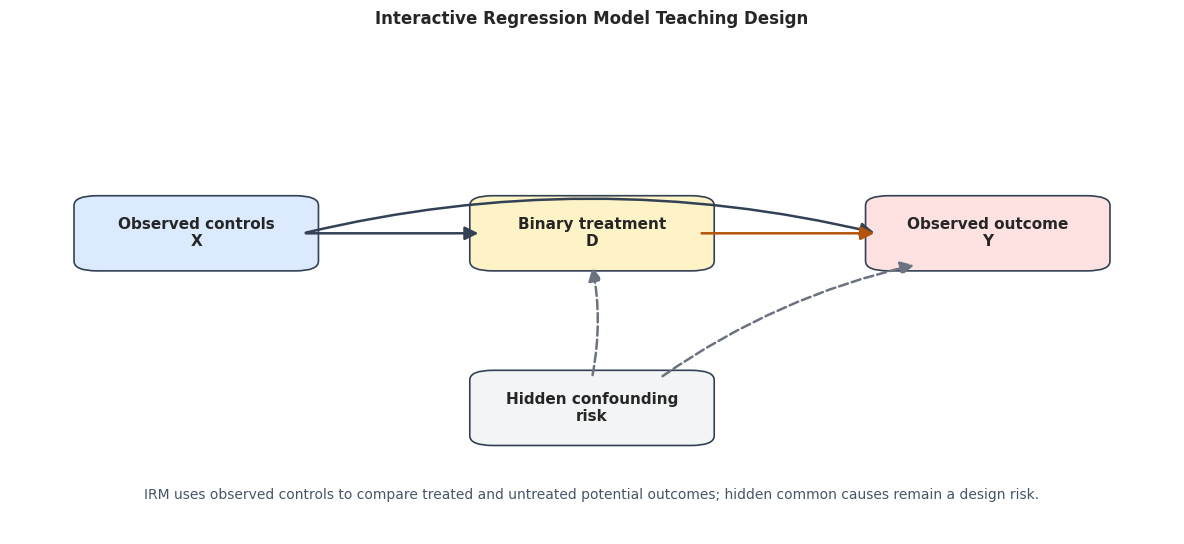

In [3]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

nodes = {
    "X": {"xy": (0.16, 0.62), "label": "Observed controls\nX", "color": "#dbeafe"},
    "D": {"xy": (0.50, 0.62), "label": "Binary treatment\nD", "color": "#fef3c7"},
    "Y": {"xy": (0.84, 0.62), "label": "Observed outcome\nY", "color": "#fee2e2"},
    "U": {"xy": (0.50, 0.26), "label": "Hidden confounding\nrisk", "color": "#f3f4f6"},
}

edge_specs = [
    ("X", "D", "#334155", "solid", 0.00),
    ("X", "Y", "#334155", "solid", -0.12),
    ("D", "Y", "#b45309", "solid", 0.00),
    ("U", "D", "#6b7280", "dashed", 0.10),
    ("U", "Y", "#6b7280", "dashed", -0.10),
]

fig, ax = plt.subplots(figsize=(12, 5.6))
ax.set_axis_off()
box_w, box_h = 0.17, 0.115

def edge_endpoint(source_xy, target_xy, from_source=True):
    x0, y0 = source_xy
    x1, y1 = target_xy
    dx, dy = x1 - x0, y1 - y0
    scale = 1.0 / max(abs(dx) / (box_w / 2), abs(dy) / (box_h / 2))
    if from_source:
        return (x0 + dx * scale * 1.08, y0 + dy * scale * 1.08)
    return (x1 - dx * scale * 1.12, y1 - dy * scale * 1.12)

for spec in nodes.values():
    x, y_pos = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y_pos - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.02",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y_pos, spec["label"], ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)

for start, end, color, style, rad in edge_specs:
    start_xy = edge_endpoint(nodes[start]["xy"], nodes[end]["xy"], from_source=True)
    end_xy = edge_endpoint(nodes[start]["xy"], nodes[end]["xy"], from_source=False)
    arrow = FancyArrowPatch(
        start_xy,
        end_xy,
        arrowstyle="-|>",
        mutation_scale=20,
        linewidth=1.8,
        color=color,
        linestyle=style,
        connectionstyle=f"arc3,rad={rad}",
        zorder=5,
    )
    ax.add_patch(arrow)

ax.text(
    0.50,
    0.08,
    "IRM uses observed controls to compare treated and untreated potential outcomes; hidden common causes remain a design risk.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("Interactive Regression Model Teaching Design", pad=18)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_irm_design_dag.png", dpi=160, bbox_inches="tight")
plt.show()

The diagram has no instrument. It is an observed-control design. That means the covariates must be rich enough to make treated and untreated units comparable after adjustment.

## Create A Teaching Dataset

We now simulate a binary-treatment dataset.

The treatment probability depends on observed controls, so the treated and untreated groups are not directly comparable. However, the treatment assignment is generated from observed controls only, so unconfoundedness holds by construction.

The treatment effect is heterogeneous: some units benefit more than others. This makes the ATE and ATT-style targets different.

In [4]:
rng = np.random.default_rng(RANDOM_STATE)
N_OBS = 4_000

feature_cols = [
    "engagement_score",
    "need_intensity",
    "content_fit",
    "recent_activity",
    "price_sensitivity",
    "tenure_signal",
    "novelty_appetite",
    "seasonality_signal",
]

X_raw = pd.DataFrame(rng.normal(size=(N_OBS, len(feature_cols))), columns=feature_cols)

true_logit = (
    -0.15
    + 0.65 * X_raw["engagement_score"]
    + 0.45 * X_raw["need_intensity"]
    - 0.50 * X_raw["price_sensitivity"]
    + 0.35 * np.sin(X_raw["content_fit"])
    + 0.25 * X_raw["recent_activity"] * X_raw["novelty_appetite"]
    - 0.20 * X_raw["seasonality_signal"]
)
true_propensity = np.clip(sigmoid(true_logit), 0.08, 0.92)
feature_exposure = rng.binomial(1, true_propensity, size=N_OBS)

true_mu0 = (
    0.80 * np.sin(X_raw["engagement_score"])
    + 0.55 * X_raw["need_intensity"] ** 2
    - 0.45 * X_raw["price_sensitivity"]
    + 0.35 * X_raw["content_fit"] * X_raw["recent_activity"]
    + 0.30 * np.cos(X_raw["seasonality_signal"])
)

true_tau = (
    0.75
    + 0.35 * sigmoid(X_raw["engagement_score"])
    + 0.30 * X_raw["need_intensity"]
    - 0.20 * X_raw["price_sensitivity"]
    + 0.15 * (X_raw["novelty_appetite"] > 0).astype(float)
)
true_mu1 = true_mu0 + true_tau

shared_noise = rng.normal(loc=0.0, scale=1.0, size=N_OBS)
potential_outcome_0 = true_mu0 + shared_noise
potential_outcome_1 = true_mu1 + shared_noise
weekly_value = np.where(feature_exposure == 1, potential_outcome_1, potential_outcome_0)

irm_df = X_raw.assign(
    feature_exposure=feature_exposure,
    weekly_value=weekly_value,
    true_propensity=true_propensity,
    true_mu0=true_mu0,
    true_mu1=true_mu1,
    true_tau=true_tau,
    potential_outcome_0=potential_outcome_0,
    potential_outcome_1=potential_outcome_1,
)

TRUE_ATE = float(irm_df["true_tau"].mean())
TRUE_ATT = float(irm_df.loc[irm_df["feature_exposure"] == 1, "true_tau"].mean())
TREATMENT_RATE = float(irm_df["feature_exposure"].mean())

irm_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_irm_data.csv", index=False)
print(f"Saved synthetic IRM data with shape {irm_df.shape}")
print(f"Treatment rate: {TREATMENT_RATE:.3f}")
print(f"True ATE: {TRUE_ATE:.3f}")
print(f"True ATT-style target: {TRUE_ATT:.3f}")
display(irm_df.head())

Saved synthetic IRM data with shape (4000, 16)
Treatment rate: 0.459
True ATE: 0.996
True ATT-style target: 1.133


,engagement_score,need_intensity,content_fit,recent_activity,price_sensitivity,tenure_signal,novelty_appetite,seasonality_signal,feature_exposure,weekly_value,true_propensity,true_mu0,true_mu1,true_tau,potential_outcome_0,potential_outcome_1
0,-0.793122,0.240571,-1.896326,1.395772,0.638295,-0.292047,-0.311949,0.303835,0,-1.008348,0.201385,-1.465574,-0.662037,0.803537,-1.008348,-0.204811
1,-0.267660,-0.225909,0.720068,0.514705,-0.064128,-0.085477,0.160916,-0.614018,0,-0.733904,0.495185,0.220266,1.217037,0.996771,-0.733904,0.262868
2,-0.403750,0.548260,-0.130483,-1.374426,-0.477279,0.656622,-0.232283,-0.148733,0,-0.257925,0.534182,0.425260,1.575338,1.150078,-0.257925,0.892153
3,0.641837,1.824610,-0.713189,1.348207,-1.230013,0.174978,-1.169530,1.351458,1,3.904644,0.692068,2.592242,4.364937,1.772695,2.131949,3.904644
4,0.833923,1.137717,-0.885533,0.684555,-0.519013,-0.457385,0.506537,0.876718,1,1.742986,0.690805,1.517669,3.106801,1.589132,0.153854,1.742986


The true ATE and ATT-style target differ because treatment is more likely for units with different expected treatment effects. That is common in observational settings: who gets treated matters.

## Field Dictionary

This table documents the role of the important columns. In real work, this step prevents a common mistake: placing outcome-derived, treatment-derived, or post-treatment columns into the controls.

In [5]:
field_dictionary = pd.DataFrame(
    [
        {"column": "weekly_value", "role": "outcome", "description": "Observed outcome Y."},
        {"column": "feature_exposure", "role": "binary treatment", "description": "Observed binary treatment D."},
        *[
            {"column": col, "role": "control", "description": "Observed pre-treatment control X."}
            for col in feature_cols
        ],
        {"column": "true_propensity", "role": "hidden teaching column", "description": "True treatment probability P(D=1 | X)."},
        {"column": "true_mu0", "role": "hidden teaching column", "description": "True E[Y(0) | X]."},
        {"column": "true_mu1", "role": "hidden teaching column", "description": "True E[Y(1) | X]."},
        {"column": "true_tau", "role": "hidden teaching column", "description": "True individual treatment effect mu1(X) - mu0(X)."},
        {"column": "potential_outcome_0", "role": "hidden teaching column", "description": "Simulated Y(0), not observed in real data for treated units."},
        {"column": "potential_outcome_1", "role": "hidden teaching column", "description": "Simulated Y(1), not observed in real data for untreated units."},
    ]
)
save_table(field_dictionary, "field_dictionary")
display(field_dictionary)

,column,role,description
0,weekly_value,outcome,Observed outcome Y.
1,feature_exposure,binary treatment,Observed binary treatment D.
2,engagement_score,control,Observed pre-treatment control X.
3,need_intensity,control,Observed pre-treatment control X.
4,content_fit,control,Observed pre-treatment control X.
5,recent_activity,control,Observed pre-treatment control X.
6,price_sensitivity,control,Observed pre-treatment control X.
7,tenure_signal,control,Observed pre-treatment control X.
8,novelty_appetite,control,Observed pre-treatment control X.
9,seasonality_signal,control,Observed pre-treatment control X.


The controls are all pre-treatment by construction. The true potential outcome columns are excluded from every model and used only to check synthetic truth.

## Basic Data Audit

Before estimating effects, we check missingness, scale, treatment support, and the true targets in the synthetic data.

In binary-treatment problems, the treated and untreated sample sizes matter. If one group is tiny, nuisance learning and overlap diagnostics become fragile.

In [6]:
audit_cols = ["weekly_value", "feature_exposure", "true_propensity", "true_tau"] + feature_cols

data_audit = pd.DataFrame(
    [
        {
            "column": column,
            "missing_rate": float(irm_df[column].isna().mean()),
            "mean": float(irm_df[column].mean()),
            "std": float(irm_df[column].std()),
            "min": float(irm_df[column].min()),
            "p05": float(irm_df[column].quantile(0.05)),
            "median": float(irm_df[column].median()),
            "p95": float(irm_df[column].quantile(0.95)),
            "max": float(irm_df[column].max()),
            "n_unique": int(irm_df[column].nunique()),
        }
        for column in audit_cols
    ]
)
save_table(data_audit, "data_audit")
display(data_audit)

target_summary = pd.DataFrame(
    [
        {"target": "Treatment rate", "value": TREATMENT_RATE},
        {"target": "True ATE", "value": TRUE_ATE},
        {"target": "True ATT-style target", "value": TRUE_ATT},
        {"target": "Treated count", "value": int(irm_df["feature_exposure"].sum())},
        {"target": "Untreated count", "value": int((1 - irm_df["feature_exposure"]).sum())},
    ]
)
save_table(target_summary, "target_summary")
display(target_summary)

,column,missing_rate,mean,std,min,p05,median,p95,max,n_unique
0,weekly_value,0.0,1.257400,1.713478,-3.970586,-1.356658,1.157832,4.236847,8.540294,4000
1,feature_exposure,0.0,0.459250,0.498399,0.000000,0.000000,0.000000,1.000000,1.000000,2
2,true_propensity,0.0,0.469063,0.208874,0.080000,0.141123,0.464328,0.819851,0.920000,3932
3,true_tau,0.0,0.996435,0.379393,-0.434153,0.376586,0.996509,1.619226,2.220412,4000
4,engagement_score,0.0,-0.017138,1.004586,-3.659392,-1.685178,-0.013643,1.577029,4.013439,4000
5,need_intensity,0.0,-0.008217,1.008047,-3.635159,-1.657538,-0.003896,1.658798,3.527216,4000
6,content_fit,0.0,0.011039,0.991930,-3.987716,-1.628396,0.014778,1.631440,3.600337,4000
7,recent_activity,0.0,-0.001082,0.998163,-3.573864,-1.594612,0.004866,1.673488,3.653308,4000
8,price_sensitivity,0.0,-0.014797,0.991680,-3.747414,-1.673546,0.006008,1.596217,3.417551,4000
9,tenure_signal,0.0,0.033066,1.014382,-4.012688,-1.662613,0.046687,1.704032,3.667511,4000


,target,value
0,Treatment rate,0.459250
1,True ATE,0.996435
2,True ATT-style target,1.132978
3,Treated count,1837.000000
4,Untreated count,2163.000000


The treatment rate is comfortably away from zero and one. That does not guarantee overlap everywhere, but it tells us both treatment groups have enough rows for the tutorial.

## Treatment Assignment Is Confounded By X

This figure shows that the true propensity score varies with observed controls. Treated units are not a random subset of all units.

The right panel shows the distribution of the true treatment effect. Since treatment effects vary across units, the ATE and ATT-style target need not match.

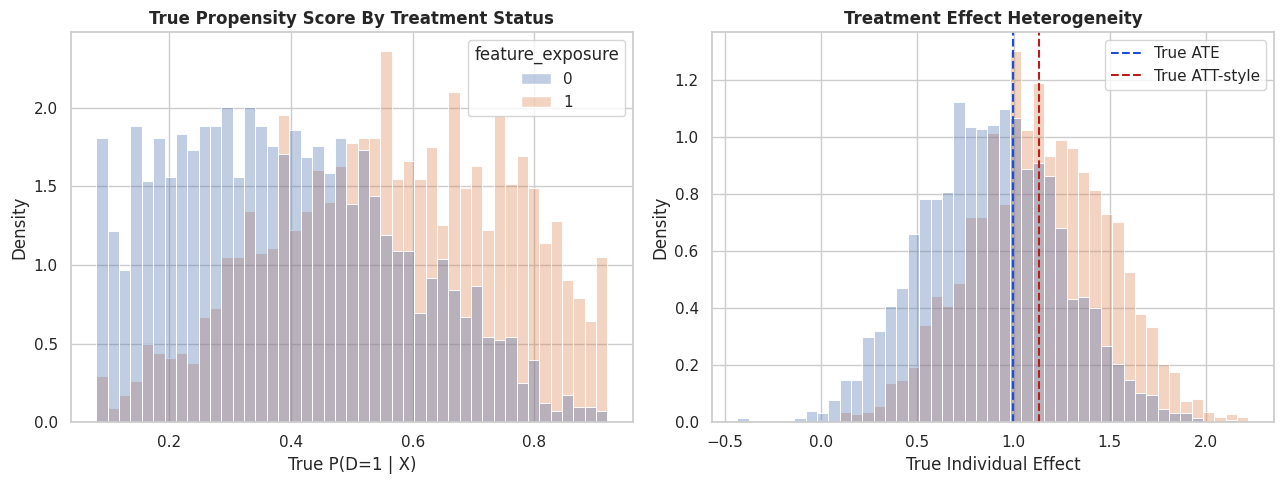

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    data=irm_df,
    x="true_propensity",
    hue="feature_exposure",
    bins=45,
    stat="density",
    common_norm=False,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title("True Propensity Score By Treatment Status")
axes[0].set_xlabel("True P(D=1 | X)")
axes[0].set_ylabel("Density")

sns.histplot(
    data=irm_df,
    x="true_tau",
    hue="feature_exposure",
    bins=45,
    stat="density",
    common_norm=False,
    alpha=0.35,
    ax=axes[1],
)
axes[1].axvline(TRUE_ATE, color="#1d4ed8", linestyle="--", linewidth=1.5, label="True ATE")
axes[1].axvline(TRUE_ATT, color="#b91c1c", linestyle="--", linewidth=1.5, label="True ATT-style")
axes[1].set_title("Treatment Effect Heterogeneity")
axes[1].set_xlabel("True Individual Effect")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_propensity_and_effect_heterogeneity.png", dpi=160, bbox_inches="tight")
plt.show()

The treated group is shifted toward higher propensities and somewhat different effects. That is exactly why a raw mean difference can miss the ATE.

## Correlation Screen

A correlation matrix is only a rough diagnostic, especially with nonlinear relationships. Still, it helps us see how treatment, outcome, true propensity, true effects, and controls relate in the synthetic data.

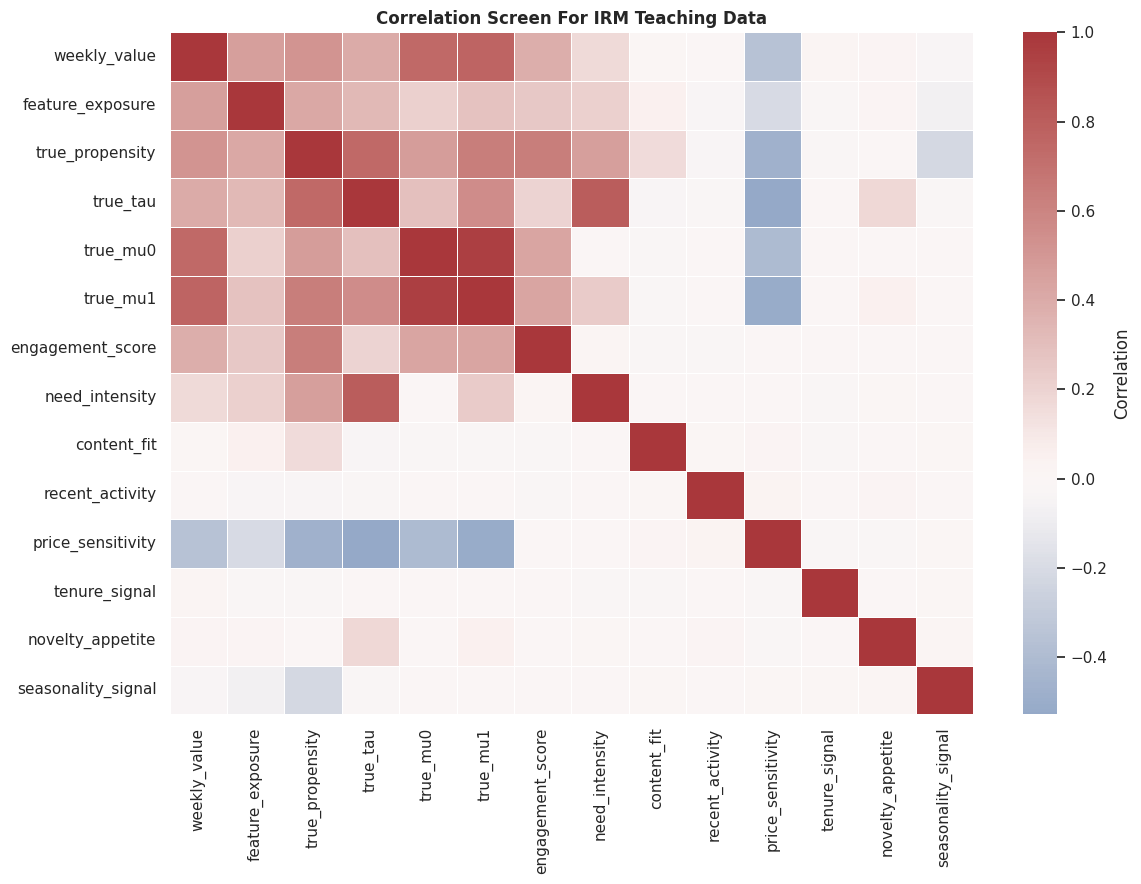

In [8]:
corr_cols = ["weekly_value", "feature_exposure", "true_propensity", "true_tau", "true_mu0", "true_mu1"] + feature_cols
corr_matrix = irm_df[corr_cols].corr()
save_table(corr_matrix.reset_index().rename(columns={"index": "column"}), "design_correlation_matrix")

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    cmap="vlag",
    center=0,
    annot=False,
    linewidths=0.4,
    cbar_kws={"label": "Correlation"},
    ax=ax,
)
ax.set_title("Correlation Screen For IRM Teaching Data")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_design_correlation_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

The matrix shows why simple comparison is risky: treatment is associated with observed controls that are also related to the outcome.

## Baseline Estimators

We start with simple baselines:

- Difference in means between treated and untreated units.
- OLS adjustment with treatment and raw controls.
- Oracle regression adjustment using the true outcome nuisance functions.
- Oracle AIPW using the true propensity and true outcome nuisance functions.

The oracle rows are available only because the data are synthetic. They show the target behavior when nuisance functions are known.

In [9]:
y = irm_df["weekly_value"].to_numpy()
d = irm_df["feature_exposure"].to_numpy()
X = irm_df[feature_cols]
true_p = irm_df["true_propensity"].to_numpy()
true_g0 = irm_df["true_mu0"].to_numpy()
true_g1 = irm_df["true_mu1"].to_numpy()

baseline_rows = []
baseline_rows.append(mean_difference_summary(y, d, "Difference in means"))
baseline_rows.append(treatment_ols_summary(irm_df["weekly_value"], irm_df[["feature_exposure"] + feature_cols], "feature_exposure", "OLS with raw controls"))
baseline_rows.append(
    {
        "estimator": "Oracle regression adjustment",
        "target": "ATE",
        "theta_hat": float(np.mean(true_g1 - true_g0)),
        "std_error": float(np.std(true_g1 - true_g0, ddof=1) / np.sqrt(len(true_g1))),
        "ci_95_lower": float(np.mean(true_g1 - true_g0) - 1.96 * np.std(true_g1 - true_g0, ddof=1) / np.sqrt(len(true_g1))),
        "ci_95_upper": float(np.mean(true_g1 - true_g0) + 1.96 * np.std(true_g1 - true_g0, ddof=1) / np.sqrt(len(true_g1))),
        "p_value": np.nan,
    }
)
baseline_rows.append(aipw_ate(y, d, true_g0, true_g1, true_p, "Oracle AIPW"))
baseline_rows.append(aipw_att(y, d, true_g0, true_p, "Oracle ATT-style AIPW"))

baseline_estimates = pd.DataFrame(baseline_rows)
baseline_estimates["true_target"] = np.where(baseline_estimates["target"].eq("ATT-style"), TRUE_ATT, TRUE_ATE)
baseline_estimates["bias_vs_target"] = baseline_estimates["theta_hat"] - baseline_estimates["true_target"]
save_table(baseline_estimates, "baseline_estimates")
display(baseline_estimates)

,estimator,target,theta_hat,std_error,ci_95_lower,ci_95_upper,p_value,true_target,bias_vs_target
0,Difference in means,unadjusted mean difference,1.595003,0.048559,1.499827,1.690179,NaN,0.996435,0.598568
1,OLS with raw controls,raw regression slope,1.045854,0.046136,0.955429,1.136279,9.075105e-114,0.996435,0.049419
2,Oracle regression adjustment,ATE,0.996435,0.005999,0.984677,1.008192,NaN,0.996435,0.000000
3,Oracle AIPW,ATE,0.945411,0.037036,0.872821,1.018001,NaN,0.996435,-0.051024
4,Oracle ATT-style AIPW,ATT-style,1.119326,0.045365,1.030411,1.208241,NaN,1.132978,-0.013652


The raw mean difference is far from the ATE because treatment assignment depends on covariates. Adjustment moves the estimate toward the causal target, and the oracle rows show what happens when the nuisance functions are known.

## Baseline Estimate Plot

This figure shows the baseline estimates. The blue dashed line marks the true ATE. The red dashed line marks the true ATT-style target.

The different reference lines matter because ATE and ATT-style targets are different in this dataset.

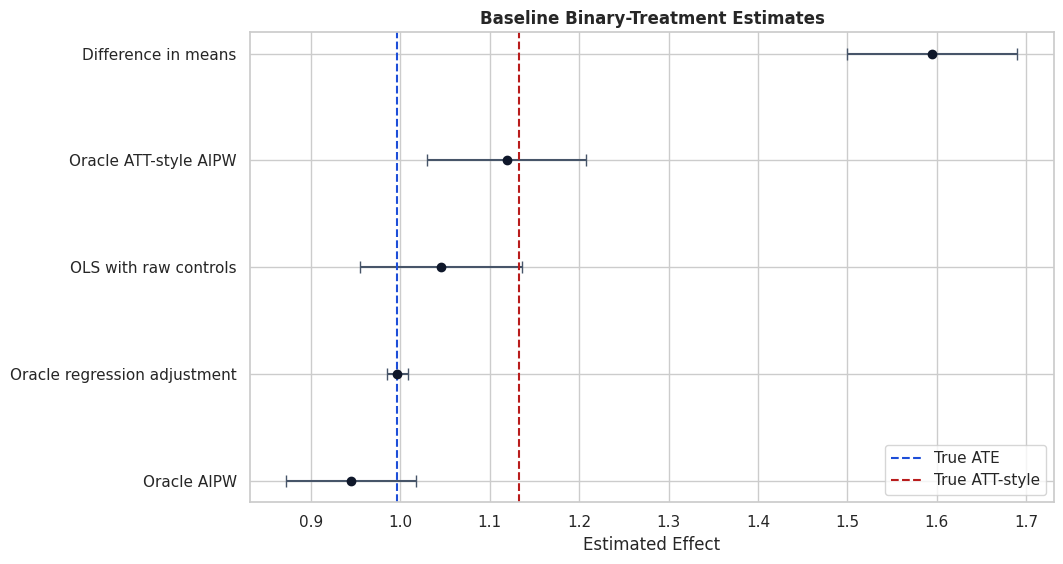

In [10]:
plot_baselines = baseline_estimates.copy().sort_values("theta_hat")
plot_baselines["lower_error"] = plot_baselines["theta_hat"] - plot_baselines["ci_95_lower"]
plot_baselines["upper_error"] = plot_baselines["ci_95_upper"] - plot_baselines["theta_hat"]

fig, ax = plt.subplots(figsize=(10.8, 5.8))
y_pos = np.arange(len(plot_baselines))
ax.errorbar(
    x=plot_baselines["theta_hat"],
    y=y_pos,
    xerr=[plot_baselines["lower_error"], plot_baselines["upper_error"]],
    fmt="o",
    color="#0f172a",
    ecolor="#475569",
    capsize=4,
)
ax.axvline(TRUE_ATE, color="#1d4ed8", linestyle="--", linewidth=1.5, label="True ATE")
ax.axvline(TRUE_ATT, color="#b91c1c", linestyle="--", linewidth=1.5, label="True ATT-style")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_baselines["estimator"])
ax.set_xlabel("Estimated Effect")
ax.set_title("Baseline Binary-Treatment Estimates")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_baseline_estimates.png", dpi=160, bbox_inches="tight")
plt.show()

The plot makes the estimand distinction visible. A raw difference can be biased, and an ATT-style target can legitimately differ from the ATE when treatment effects vary.

## Nuisance Learners

We will compare two nuisance specifications:

- regularized linear/logistic learners;
- histogram gradient boosting learners.

`ml_g` is a regressor because the outcome is continuous. `ml_m` is a classifier because it estimates the propensity score.

In [11]:
linear_outcome_learner = make_pipeline(
    StandardScaler(),
    LassoCV(cv=3, random_state=RANDOM_STATE, max_iter=5_000),
)
linear_propensity_learner = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        cv=3,
        max_iter=2_000,
        scoring="neg_log_loss",
        random_state=RANDOM_STATE,
    ),
)

hgb_outcome_learner = HistGradientBoostingRegressor(
    max_iter=240,
    learning_rate=0.04,
    max_leaf_nodes=24,
    l2_regularization=0.001,
    random_state=RANDOM_STATE,
)
hgb_propensity_learner = HistGradientBoostingClassifier(
    max_iter=240,
    learning_rate=0.04,
    max_leaf_nodes=24,
    l2_regularization=0.001,
    random_state=RANDOM_STATE,
)

learner_catalog = pd.DataFrame(
    [
        {"learner_name": "Regularized linear outcome + logistic propensity", "use_case": "Transparent baseline; may underfit nonlinear nuisance functions."},
        {"learner_name": "Gradient-boosted outcome + propensity", "use_case": "Captures nonlinearities and interactions in this synthetic design."},
    ]
)
save_table(learner_catalog, "learner_catalog")
display(learner_catalog)

,learner_name,use_case
0,Regularized linear outcome + logistic propensity,Transparent baseline; may underfit nonlinear n...
1,Gradient-boosted outcome + propensity,Captures nonlinearities and interactions in th...


The nuisance learners are not the final estimand. They are tools for estimating the outcome regressions and propensity score used in the orthogonal score.

## Manual Cross-Fitted AIPW

Before fitting DoubleML, we manually compute cross-fitted AIPW estimates.

The manual procedure estimates three nuisance quantities out of fold:

- `g0_hat(X)`: predicted outcome if untreated;
- `g1_hat(X)`: predicted outcome if treated;
- `m_hat(X)`: predicted probability of treatment.

Each row's nuisance predictions come from models that did not train on that row.

In [12]:
manual_g0_hat, manual_g1_hat, manual_m_hat = crossfit_irm_nuisances(
    X=X,
    y=y,
    d=d,
    outcome_learner=hgb_outcome_learner,
    propensity_learner=hgb_propensity_learner,
    n_splits=5,
    random_state=RANDOM_STATE,
)

manual_estimates = pd.DataFrame(
    [
        ipw_ate(y, d, manual_m_hat, "Manual cross-fitted IPW"),
        aipw_ate(y, d, manual_g0_hat, manual_g1_hat, manual_m_hat, "Manual cross-fitted AIPW"),
        aipw_att(y, d, manual_g0_hat, manual_m_hat, "Manual cross-fitted ATT-style AIPW"),
    ]
)
manual_estimates["true_target"] = np.where(manual_estimates["target"].eq("ATT-style"), TRUE_ATT, TRUE_ATE)
manual_estimates["bias_vs_target"] = manual_estimates["theta_hat"] - manual_estimates["true_target"]
save_table(manual_estimates, "manual_crossfit_estimates")
display(manual_estimates)

,estimator,target,theta_hat,std_error,ci_95_lower,ci_95_upper,p_value,true_target,bias_vs_target
0,Manual cross-fitted IPW,ATE,1.039355,0.087898,0.867075,1.211634,NaN,0.996435,0.04292
1,Manual cross-fitted AIPW,ATE,0.961524,0.052736,0.858163,1.064886,NaN,0.996435,-0.03491
2,Manual cross-fitted ATT-style AIPW,ATT-style,1.116128,0.064518,0.989673,1.242583,NaN,1.132978,-0.01685


The AIPW estimate uses both outcome regression and propensity weighting. In this synthetic design, it is much closer to the target than the raw mean difference.

## Manual Nuisance Quality

Because the data are synthetic, we can compare the cross-fitted nuisance predictions to the true nuisance functions.

In real data, the true nuisance functions are unknown. We would instead inspect out-of-fold errors, propensity calibration, overlap, and domain plausibility.

In [13]:
manual_nuisance_quality = pd.DataFrame(
    [
        {
            "nuisance": "g0(X) = E[Y(0) | X]",
            "rmse_vs_truth": rmse(true_g0, manual_g0_hat),
            "mae_vs_truth": float(mean_absolute_error(true_g0, manual_g0_hat)),
            "correlation_vs_truth": float(np.corrcoef(true_g0, manual_g0_hat)[0, 1]),
        },
        {
            "nuisance": "g1(X) = E[Y(1) | X]",
            "rmse_vs_truth": rmse(true_g1, manual_g1_hat),
            "mae_vs_truth": float(mean_absolute_error(true_g1, manual_g1_hat)),
            "correlation_vs_truth": float(np.corrcoef(true_g1, manual_g1_hat)[0, 1]),
        },
        {
            "nuisance": "m(X) = P(D=1 | X)",
            "rmse_vs_truth": rmse(true_p, manual_m_hat),
            "mae_vs_truth": float(mean_absolute_error(true_p, manual_m_hat)),
            "correlation_vs_truth": float(np.corrcoef(true_p, manual_m_hat)[0, 1]),
            "auc_for_treatment": float(roc_auc_score(d, manual_m_hat)),
            "log_loss_for_treatment": float(log_loss(d, manual_m_hat)),
        },
    ]
)
save_table(manual_nuisance_quality, "manual_nuisance_quality")
display(manual_nuisance_quality)

,nuisance,rmse_vs_truth,mae_vs_truth,correlation_vs_truth,auc_for_treatment,log_loss_for_treatment
0,g0(X) = E[Y(0) | X],0.437118,0.326555,0.917330,NaN,NaN
1,g1(X) = E[Y(1) | X],0.500857,0.370106,0.922514,NaN,NaN
2,m(X) = P(D=1 | X),0.127586,0.099716,0.846321,0.703504,0.635537


The nuisance models recover the broad structure but are not perfect. AIPW is designed to tolerate nuisance error better than a simple plug-in estimator, especially with cross-fitting.

## Propensity Overlap Diagnostics

Overlap means treated and untreated units exist across the relevant covariate space. Propensity scores near zero or one create large inverse-propensity weights and unstable estimates.

This cell summarizes the manual cross-fitted propensity predictions and the implied weights.

In [14]:
weight_treated = d / manual_m_hat
weight_untreated = (1 - d) / (1 - manual_m_hat)
combined_ipw_weight = weight_treated + weight_untreated

propensity_diagnostics = pd.DataFrame(
    [
        {
            "diagnostic": "predicted propensity minimum",
            "value": float(np.min(manual_m_hat)),
        },
        {
            "diagnostic": "predicted propensity p05",
            "value": float(np.quantile(manual_m_hat, 0.05)),
        },
        {
            "diagnostic": "predicted propensity median",
            "value": float(np.median(manual_m_hat)),
        },
        {
            "diagnostic": "predicted propensity p95",
            "value": float(np.quantile(manual_m_hat, 0.95)),
        },
        {
            "diagnostic": "predicted propensity maximum",
            "value": float(np.max(manual_m_hat)),
        },
        {
            "diagnostic": "IPW effective sample size",
            "value": weighted_effective_sample_size(combined_ipw_weight),
        },
        {
            "diagnostic": "maximum IPW weight",
            "value": float(np.max(combined_ipw_weight)),
        },
    ]
)
save_table(propensity_diagnostics, "manual_propensity_diagnostics")
display(propensity_diagnostics)

,diagnostic,value
0,predicted propensity minimum,0.020000
1,predicted propensity p05,0.096206
2,predicted propensity median,0.440074
3,predicted propensity p95,0.863000
4,predicted propensity maximum,0.980000
5,IPW effective sample size,2299.346366
6,maximum IPW weight,33.762843


The predicted propensities stay away from zero and one. That is a healthy sign for this teaching dataset. In real data, this table is one of the first places to look for overlap trouble.

## Propensity And Weight Plots

The left panel shows propensity overlap by treatment status. The right panel shows inverse-propensity weights on a log scale.

A small number of extreme weights can dominate an estimate, so weight diagnostics should be routine in IRM workflows.

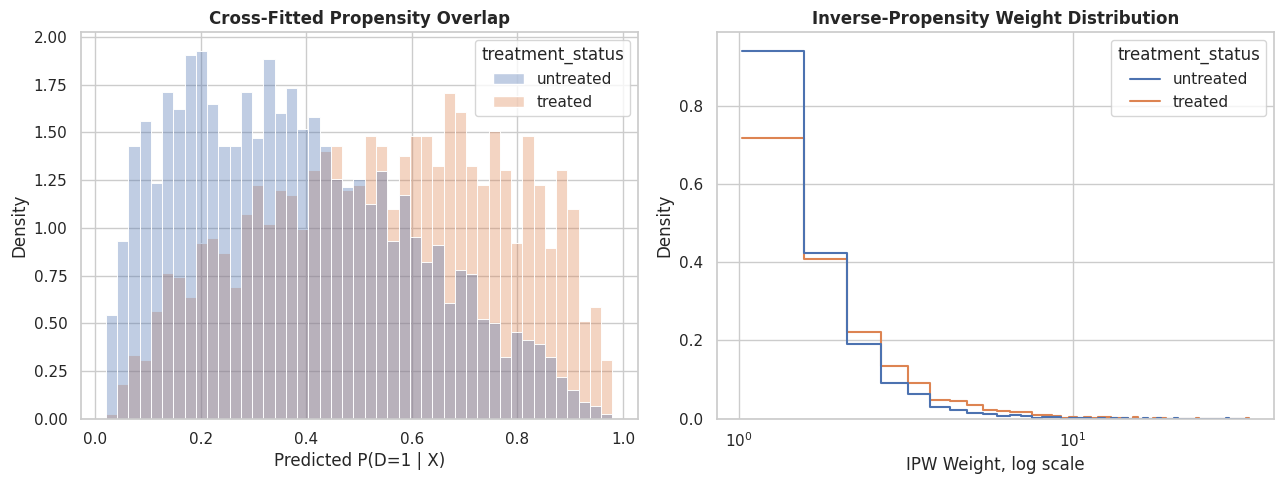

In [15]:
propensity_plot_df = pd.DataFrame(
    {
        "predicted_propensity": manual_m_hat,
        "feature_exposure": d,
        "ipw_weight": combined_ipw_weight,
    }
)
propensity_plot_df["treatment_status"] = np.where(propensity_plot_df["feature_exposure"] == 1, "treated", "untreated")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(
    data=propensity_plot_df,
    x="predicted_propensity",
    hue="treatment_status",
    bins=45,
    stat="density",
    common_norm=False,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title("Cross-Fitted Propensity Overlap")
axes[0].set_xlabel("Predicted P(D=1 | X)")

sns.histplot(
    data=propensity_plot_df,
    x="ipw_weight",
    hue="treatment_status",
    bins=60,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_title("Inverse-Propensity Weight Distribution")
axes[1].set_xlabel("IPW Weight, log scale")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_propensity_overlap_and_weights.png", dpi=160, bbox_inches="tight")
plt.show()

The overlap is not perfect, but both treatment groups have support over much of the propensity range. The weight plot does not show a severe tail problem.

## Outcome Nuisance Diagnostics

The next figure compares the manually cross-fitted outcome nuisance predictions against the true outcome nuisance functions.

The treated outcome model is trained only on treated rows, and the untreated outcome model is trained only on untreated rows. Cross-fitting keeps the displayed predictions out of fold.

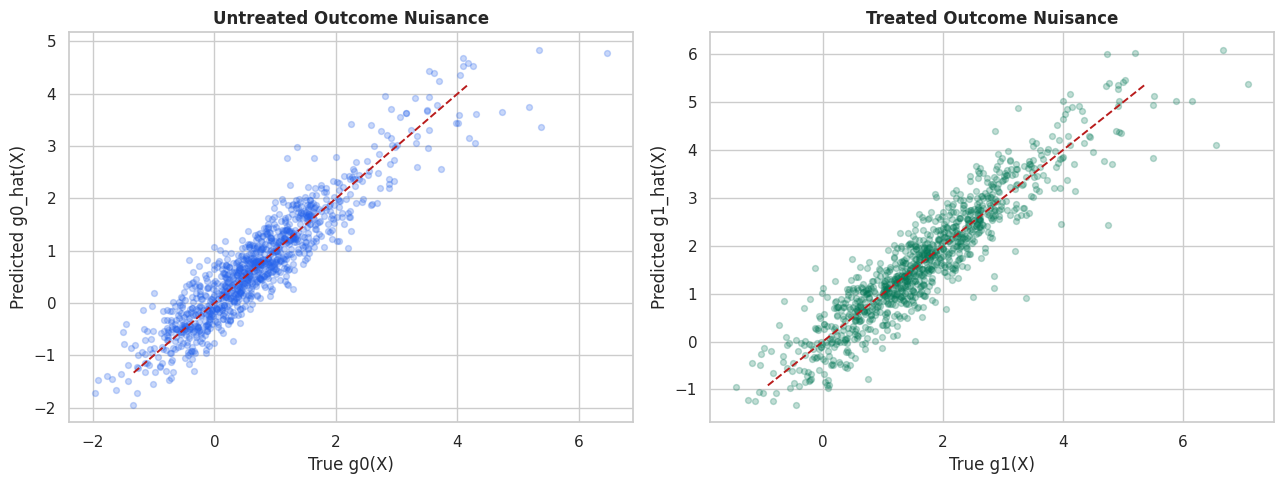

In [16]:
sample_idx = irm_df.sample(1_000, random_state=RANDOM_STATE).index

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(true_g0[sample_idx], manual_g0_hat[sample_idx], alpha=0.25, s=18, color="#2563eb")
lower0 = min(np.quantile(true_g0, 0.01), np.quantile(manual_g0_hat, 0.01))
upper0 = max(np.quantile(true_g0, 0.99), np.quantile(manual_g0_hat, 0.99))
axes[0].plot([lower0, upper0], [lower0, upper0], color="#b91c1c", linestyle="--", linewidth=1.4)
axes[0].set_title("Untreated Outcome Nuisance")
axes[0].set_xlabel("True g0(X)")
axes[0].set_ylabel("Predicted g0_hat(X)")

axes[1].scatter(true_g1[sample_idx], manual_g1_hat[sample_idx], alpha=0.25, s=18, color="#047857")
lower1 = min(np.quantile(true_g1, 0.01), np.quantile(manual_g1_hat, 0.01))
upper1 = max(np.quantile(true_g1, 0.99), np.quantile(manual_g1_hat, 0.99))
axes[1].plot([lower1, upper1], [lower1, upper1], color="#b91c1c", linestyle="--", linewidth=1.4)
axes[1].set_title("Treated Outcome Nuisance")
axes[1].set_xlabel("True g1(X)")
axes[1].set_ylabel("Predicted g1_hat(X)")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_manual_outcome_nuisance_quality.png", dpi=160, bbox_inches="tight")
plt.show()

The outcome models capture most of the pattern, with some shrinkage at the tails. That is typical for tree-based learners and finite data.

## Build The DoubleML Data Object

The `DoubleMLData` object stores the role assignment:

- `weekly_value` is the outcome.
- `feature_exposure` is the binary treatment.
- the feature columns are pre-treatment controls.

Hidden teaching columns are excluded.

In [17]:
dml_data = DoubleMLData(
    irm_df[["weekly_value", "feature_exposure"] + feature_cols],
    y_col="weekly_value",
    d_cols="feature_exposure",
    x_cols=feature_cols,
)

backend_summary = pd.DataFrame(
    [
        {"role": "outcome", "columns": dml_data.y_col},
        {"role": "treatment", "columns": ", ".join(dml_data.d_cols)},
        {"role": "controls", "columns": ", ".join(dml_data.x_cols)},
        {"role": "number_of_observations", "columns": str(dml_data.n_obs)},
    ]
)
save_table(backend_summary, "doublemldata_backend_summary")
display(backend_summary)

,role,columns
0,outcome,weekly_value
1,treatment,feature_exposure
2,controls,"engagement_score, need_intensity, content_fit,..."
3,number_of_observations,4000


This backend is intentionally simple: one outcome, one binary treatment, and observed controls. The real work is deciding whether those controls support an observed-control causal design.

## Fit `DoubleMLIRM` For ATE And ATTE

We now fit four DoubleML models:

- linear/logistic nuisance ATE;
- linear/logistic nuisance ATTE;
- gradient-boosted nuisance ATE;
- gradient-boosted nuisance ATTE.

The score option changes the target. `score="ATE"` targets the population average effect. `score="ATTE"` targets the effect among treated units.

In [18]:
irm_model_specs = {
    "Linear nuisance IRM ATE": {
        "ml_g": linear_outcome_learner,
        "ml_m": linear_propensity_learner,
        "score": "ATE",
        "true_target": TRUE_ATE,
    },
    "Linear nuisance IRM ATTE": {
        "ml_g": linear_outcome_learner,
        "ml_m": linear_propensity_learner,
        "score": "ATTE",
        "true_target": TRUE_ATT,
    },
    "Gradient boosting nuisance IRM ATE": {
        "ml_g": hgb_outcome_learner,
        "ml_m": hgb_propensity_learner,
        "score": "ATE",
        "true_target": TRUE_ATE,
    },
    "Gradient boosting nuisance IRM ATTE": {
        "ml_g": hgb_outcome_learner,
        "ml_m": hgb_propensity_learner,
        "score": "ATTE",
        "true_target": TRUE_ATT,
    },
}

irm_models = {}
for model_name, spec in irm_model_specs.items():
    model = DoubleMLIRM(
        dml_data,
        ml_g=clone(spec["ml_g"]),
        ml_m=clone(spec["ml_m"]),
        n_folds=5,
        n_rep=1,
        score=spec["score"],
    )
    model.fit(store_predictions=True)
    irm_models[model_name] = model
    print(f"Finished: {model_name}")

irm_summary_rows = []
for model_name, model in irm_models.items():
    summary = model.summary.reset_index().rename(columns={"index": "treatment"})
    row = summary.iloc[0].to_dict()
    true_target = irm_model_specs[model_name]["true_target"]
    irm_summary_rows.append(
        {
            "estimator": model_name,
            "score": irm_model_specs[model_name]["score"],
            "treatment": row["treatment"],
            "theta_hat": row["coef"],
            "std_error": row["std err"],
            "t_stat": row["t"],
            "p_value": row["P>|t|"],
            "ci_95_lower": row["2.5 %"],
            "ci_95_upper": row["97.5 %"],
            "true_target": true_target,
            "bias_vs_target": row["coef"] - true_target,
        }
    )

irm_summary = pd.DataFrame(irm_summary_rows)
save_table(irm_summary, "doubleml_irm_summary")
display(irm_summary)

Finished: Linear nuisance IRM ATE


Finished: Linear nuisance IRM ATTE


Finished: Gradient boosting nuisance IRM ATE


Finished: Gradient boosting nuisance IRM ATTE


,estimator,score,treatment,theta_hat,std_error,t_stat,p_value,ci_95_lower,ci_95_upper,true_target,bias_vs_target
0,Linear nuisance IRM ATE,ATE,feature_exposure,1.027968,0.056428,18.217240,3.766794e-74,0.917370,1.138565,0.996435,0.031533
1,Linear nuisance IRM ATTE,ATTE,feature_exposure,1.162320,0.057914,20.069872,1.353534e-89,1.048812,1.275829,1.132978,0.029342
2,Gradient boosting nuisance IRM ATE,ATE,feature_exposure,0.985272,0.053888,18.283853,1.112793e-74,0.879654,1.090890,0.996435,-0.011163
3,Gradient boosting nuisance IRM ATTE,ATTE,feature_exposure,1.048266,0.069878,15.001366,7.192421e-51,0.911308,1.185224,1.132978,-0.084712


The gradient-boosted nuisance specification is expected to do well because the synthetic treatment assignment and outcome functions are nonlinear. The linear/logistic specification remains useful as a transparent baseline.

## Compare All Estimators

This table combines simple baselines, manual cross-fitted estimates, and DoubleML estimates.

When reading the table, compare each row to the right target. ATE rows should be compared with the true ATE. ATT-style and ATTE rows should be compared with the true treated target.

In [19]:
comparison_rows = []
comparison_rows.append(baseline_estimates)
comparison_rows.append(manual_estimates)
comparison_rows.append(
    irm_summary.rename(columns={"score": "target"})[
        ["estimator", "target", "theta_hat", "std_error", "ci_95_lower", "ci_95_upper", "p_value", "true_target", "bias_vs_target"]
    ]
)

all_estimates = pd.concat(comparison_rows, ignore_index=True, sort=False)
all_estimates["target"] = all_estimates["target"].replace({"ATTE": "ATT-style"})
all_estimates["abs_bias_vs_target"] = all_estimates["bias_vs_target"].abs()
save_table(all_estimates, "all_estimator_comparison")
display(all_estimates.sort_values("abs_bias_vs_target"))

,estimator,target,theta_hat,std_error,ci_95_lower,ci_95_upper,p_value,true_target,bias_vs_target,abs_bias_vs_target
2,Oracle regression adjustment,ATE,0.996435,0.005999,0.984677,1.008192,NaN,0.996435,0.000000,0.000000
10,Gradient boosting nuisance IRM ATE,ATE,0.985272,0.053888,0.879654,1.090890,1.112793e-74,0.996435,-0.011163,0.011163
4,Oracle ATT-style AIPW,ATT-style,1.119326,0.045365,1.030411,1.208241,NaN,1.132978,-0.013652,0.013652
7,Manual cross-fitted ATT-style AIPW,ATT-style,1.116128,0.064518,0.989673,1.242583,NaN,1.132978,-0.016850,0.016850
9,Linear nuisance IRM ATTE,ATT-style,1.162320,0.057914,1.048812,1.275829,1.353534e-89,1.132978,0.029342,0.029342
8,Linear nuisance IRM ATE,ATE,1.027968,0.056428,0.917370,1.138565,3.766794e-74,0.996435,0.031533,0.031533
6,Manual cross-fitted AIPW,ATE,0.961524,0.052736,0.858163,1.064886,NaN,0.996435,-0.034910,0.034910
5,Manual cross-fitted IPW,ATE,1.039355,0.087898,0.867075,1.211634,NaN,0.996435,0.042920,0.042920
1,OLS with raw controls,raw regression slope,1.045854,0.046136,0.955429,1.136279,9.075105e-114,0.996435,0.049419,0.049419
3,Oracle AIPW,ATE,0.945411,0.037036,0.872821,1.018001,NaN,0.996435,-0.051024,0.051024


The comparison shows the point of IRM: use outcome and propensity nuisance models to adjust for the observed differences between treated and untreated units.

## Estimate Comparison Plot

The next figure compares estimates with confidence intervals. The vertical reference lines mark the true ATE and true ATT-style target from the synthetic data.

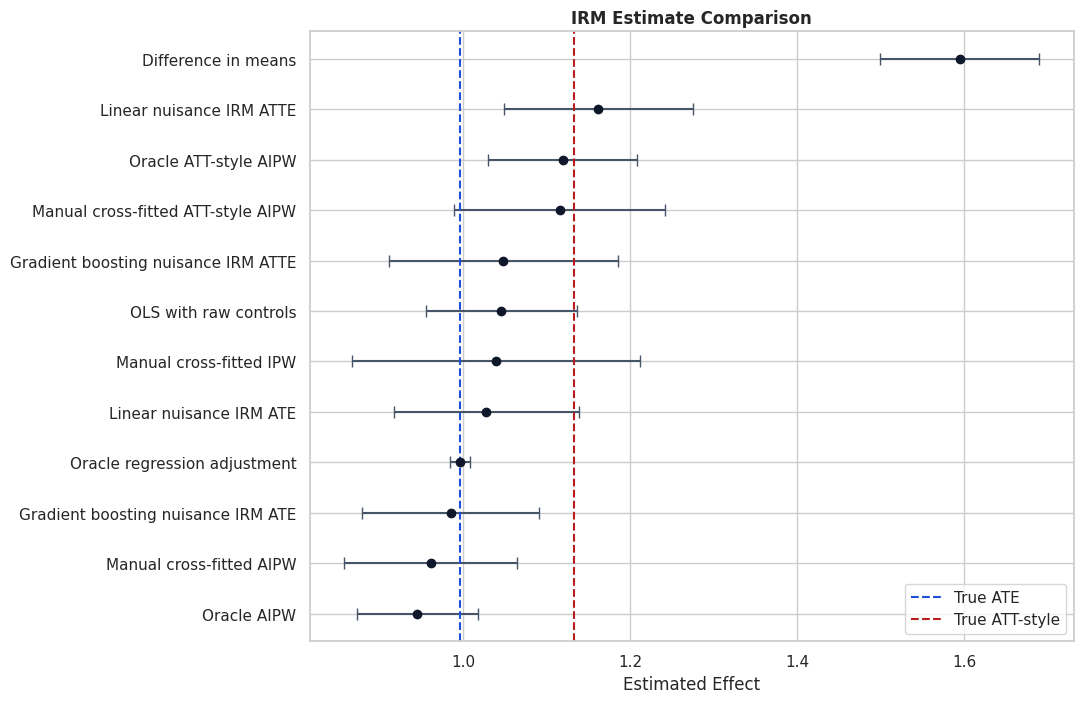

In [20]:
plot_estimates = all_estimates.copy().sort_values("theta_hat")
plot_estimates["lower_error"] = plot_estimates["theta_hat"] - plot_estimates["ci_95_lower"]
plot_estimates["upper_error"] = plot_estimates["ci_95_upper"] - plot_estimates["theta_hat"]

fig, ax = plt.subplots(figsize=(11, 7.2))
y_pos = np.arange(len(plot_estimates))
ax.errorbar(
    x=plot_estimates["theta_hat"],
    y=y_pos,
    xerr=[plot_estimates["lower_error"], plot_estimates["upper_error"]],
    fmt="o",
    color="#0f172a",
    ecolor="#475569",
    capsize=4,
)
ax.axvline(TRUE_ATE, color="#1d4ed8", linestyle="--", linewidth=1.5, label="True ATE")
ax.axvline(TRUE_ATT, color="#b91c1c", linestyle="--", linewidth=1.5, label="True ATT-style")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_estimates["estimator"])
ax.set_xlabel("Estimated Effect")
ax.set_title("IRM Estimate Comparison")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_irm_estimate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

The plot shows both bias reduction and estimand differences. ATE and ATT-style estimates should not be forced to agree when treatment effects are heterogeneous.

## DoubleML Nuisance Losses

`evaluate_learners()` reports out-of-fold nuisance losses. For IRM, the keys are:

- `ml_g0`: untreated outcome nuisance;
- `ml_g1`: treated outcome nuisance;
- `ml_m`: propensity score nuisance.

The loss values are diagnostics, not causal proof. A good propensity model cannot fix unobserved confounding.

In [21]:
loss_tables = []
for model_name, model in irm_models.items():
    loss_tables.append(learner_loss_table(model, model_name))

nuisance_losses = pd.concat(loss_tables, ignore_index=True)
save_table(nuisance_losses, "doubleml_nuisance_losses")
display(nuisance_losses)

,model,learner,mean_loss,min_loss,max_loss
0,Linear nuisance IRM ATE,ml_g0,1.314451,1.314451,1.314451
1,Linear nuisance IRM ATE,ml_g1,1.310666,1.310666,1.310666
2,Linear nuisance IRM ATE,ml_m,0.456163,0.456163,0.456163
3,Linear nuisance IRM ATTE,ml_g0,1.312939,1.312939,1.312939
4,Linear nuisance IRM ATTE,ml_g1,1.309140,1.309140,1.309140
5,Linear nuisance IRM ATTE,ml_m,0.455825,0.455825,0.455825
6,Gradient boosting nuisance IRM ATE,ml_g0,1.086616,1.086616,1.086616
7,Gradient boosting nuisance IRM ATE,ml_g1,1.063938,1.063938,1.063938
8,Gradient boosting nuisance IRM ATE,ml_m,0.470521,0.470521,0.470521
9,Gradient boosting nuisance IRM ATTE,ml_g0,1.086821,1.086821,1.086821


The loss table helps compare nuisance specifications. Lower nuisance loss is useful, but the final causal estimate also depends on overlap and identification assumptions.

## Extract DoubleML Predictions

We now pull the nuisance predictions from the gradient-boosted ATE model. These predictions are useful for diagnostics and for connecting DoubleML output back to the manual AIPW formula.

In [22]:
irm_hgb_ate = irm_models["Gradient boosting nuisance IRM ATE"]
dml_g0_hat = prediction_vector(irm_hgb_ate, "ml_g0")
dml_g1_hat = prediction_vector(irm_hgb_ate, "ml_g1")
dml_m_hat = np.clip(prediction_vector(irm_hgb_ate, "ml_m"), 0.02, 0.98)

dml_prediction_quality = pd.DataFrame(
    [
        {
            "nuisance": "ml_g0 untreated outcome",
            "rmse_vs_truth": rmse(true_g0, dml_g0_hat),
            "mae_vs_truth": float(mean_absolute_error(true_g0, dml_g0_hat)),
            "correlation_vs_truth": float(np.corrcoef(true_g0, dml_g0_hat)[0, 1]),
        },
        {
            "nuisance": "ml_g1 treated outcome",
            "rmse_vs_truth": rmse(true_g1, dml_g1_hat),
            "mae_vs_truth": float(mean_absolute_error(true_g1, dml_g1_hat)),
            "correlation_vs_truth": float(np.corrcoef(true_g1, dml_g1_hat)[0, 1]),
        },
        {
            "nuisance": "ml_m propensity",
            "rmse_vs_truth": rmse(true_p, dml_m_hat),
            "mae_vs_truth": float(mean_absolute_error(true_p, dml_m_hat)),
            "correlation_vs_truth": float(np.corrcoef(true_p, dml_m_hat)[0, 1]),
            "auc_for_treatment": float(roc_auc_score(d, dml_m_hat)),
            "log_loss_for_treatment": float(log_loss(d, dml_m_hat)),
        },
    ]
)
save_table(dml_prediction_quality, "hgb_nuisance_quality_against_truth")
display(dml_prediction_quality)

,nuisance,rmse_vs_truth,mae_vs_truth,correlation_vs_truth,auc_for_treatment,log_loss_for_treatment
0,ml_g0 untreated outcome,0.445073,0.329864,0.914579,NaN,NaN
1,ml_g1 treated outcome,0.496318,0.366543,0.922845,NaN,NaN
2,ml_m propensity,0.125739,0.098033,0.849808,0.702208,0.637294


The DoubleML nuisance predictions have similar quality to the manual cross-fitted nuisance predictions. That is expected because they use the same learner family and the same core cross-fitting idea.

## DoubleML Propensity Diagnostics

This cell summarizes the propensity predictions from the main DoubleML ATE model and the corresponding weights.

In [23]:
dml_ipw_weight = d / dml_m_hat + (1 - d) / (1 - dml_m_hat)

dml_propensity_diagnostics = pd.DataFrame(
    [
        {"diagnostic": "predicted propensity minimum", "value": float(np.min(dml_m_hat))},
        {"diagnostic": "predicted propensity p05", "value": float(np.quantile(dml_m_hat, 0.05))},
        {"diagnostic": "predicted propensity median", "value": float(np.median(dml_m_hat))},
        {"diagnostic": "predicted propensity p95", "value": float(np.quantile(dml_m_hat, 0.95))},
        {"diagnostic": "predicted propensity maximum", "value": float(np.max(dml_m_hat))},
        {"diagnostic": "IPW effective sample size", "value": weighted_effective_sample_size(dml_ipw_weight)},
        {"diagnostic": "maximum IPW weight", "value": float(np.max(dml_ipw_weight))},
    ]
)
save_table(dml_propensity_diagnostics, "doubleml_propensity_diagnostics")
display(dml_propensity_diagnostics)

,diagnostic,value
0,predicted propensity minimum,0.020000
1,predicted propensity p05,0.100421
2,predicted propensity median,0.440048
3,predicted propensity p95,0.862390
4,predicted propensity maximum,0.980000
5,IPW effective sample size,2225.352824
6,maximum IPW weight,41.088665


The propensity distribution is well behaved here. In real data, high maximum weights or a low effective sample size would lead to trimming, redesign, or a more limited target population.

## DoubleML Nuisance Plots

This figure checks the gradient-boosted DoubleML nuisance predictions against true nuisance functions from the simulation.

The third panel compares predicted and true propensities. This is a useful calibration-style check in synthetic data.

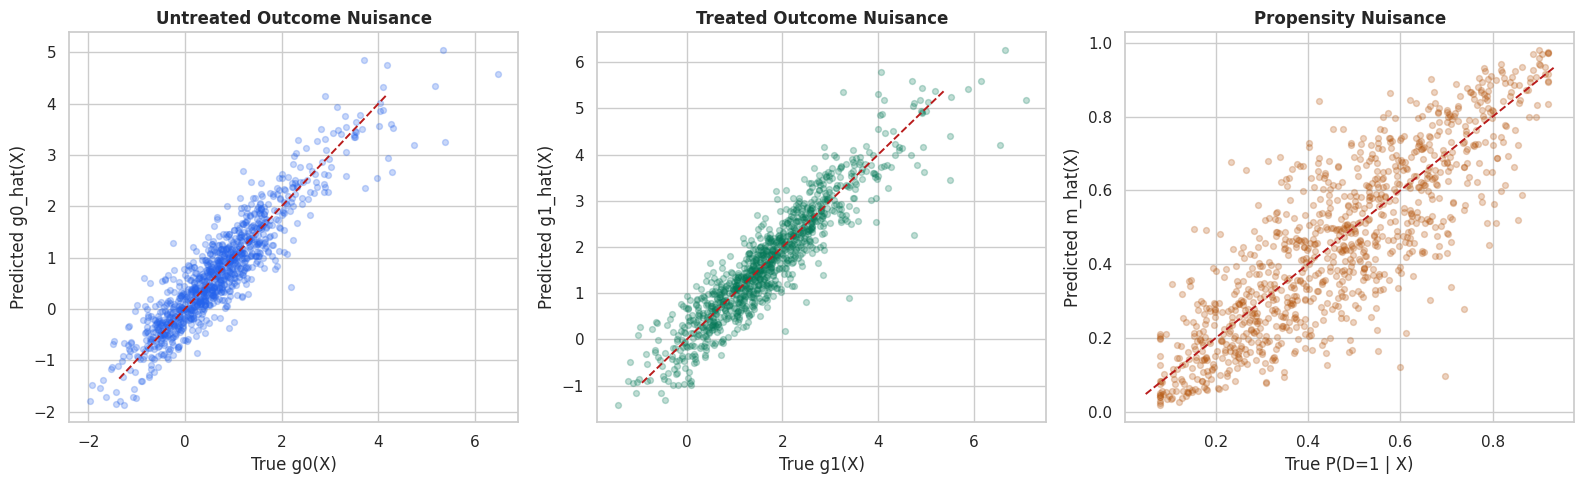

In [24]:
sample_idx = irm_df.sample(1_000, random_state=RANDOM_STATE).index

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_specs = [
    (true_g0, dml_g0_hat, "Untreated Outcome Nuisance", "True g0(X)", "Predicted g0_hat(X)", "#2563eb"),
    (true_g1, dml_g1_hat, "Treated Outcome Nuisance", "True g1(X)", "Predicted g1_hat(X)", "#047857"),
    (true_p, dml_m_hat, "Propensity Nuisance", "True P(D=1 | X)", "Predicted m_hat(X)", "#b45309"),
]

for ax, (truth, pred, title, xlabel, ylabel, color) in zip(axes, plot_specs):
    ax.scatter(truth[sample_idx], pred[sample_idx], alpha=0.25, s=18, color=color)
    lower = min(np.quantile(truth, 0.01), np.quantile(pred, 0.01))
    upper = max(np.quantile(truth, 0.99), np.quantile(pred, 0.99))
    ax.plot([lower, upper], [lower, upper], color="#b91c1c", linestyle="--", linewidth=1.4)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_doubleml_nuisance_prediction_quality.png", dpi=160, bbox_inches="tight")
plt.show()

The nuisance plots show useful but imperfect recovery. That is normal: orthogonal scores are built for realistic nuisance error, not perfect prediction.

## Score Contributions

DoubleML stores orthogonal score contributions in `psi`. At the fitted estimate, the average score should be close to zero.

Large tails in the score distribution can point to extreme weights, poor overlap, or influential observations.

,mean,std,p01,p05,median,p95,p99
0,-3.552714e-17,3.408574,-9.700456,-4.214624,-0.035836,4.012218,9.763326


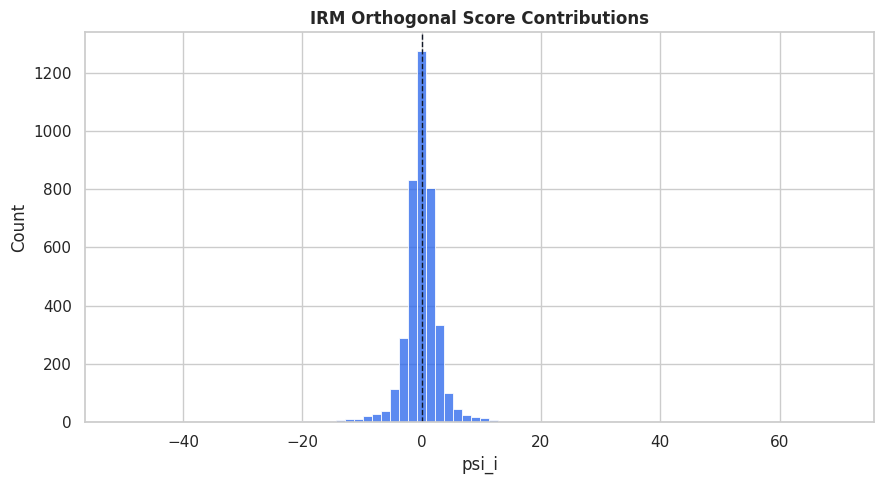

In [25]:
psi_values = np.asarray(irm_hgb_ate.psi)[:, 0, 0]
psi_summary = pd.DataFrame(
    [
        {
            "mean": float(np.mean(psi_values)),
            "std": float(np.std(psi_values, ddof=1)),
            "p01": float(np.quantile(psi_values, 0.01)),
            "p05": float(np.quantile(psi_values, 0.05)),
            "median": float(np.median(psi_values)),
            "p95": float(np.quantile(psi_values, 0.95)),
            "p99": float(np.quantile(psi_values, 0.99)),
        }
    ]
)
save_table(psi_summary, "orthogonal_score_summary")
display(psi_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(psi_values, bins=80, color="#2563eb", alpha=0.75, ax=ax)
ax.axvline(0, color="#111827", linewidth=1, linestyle="--")
ax.set_title("IRM Orthogonal Score Contributions")
ax.set_xlabel("psi_i")
ax.set_ylabel("Count")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_orthogonal_score_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

The score is centered near zero, as expected. The tails are not extreme in this well-overlapped synthetic dataset.

## Bootstrap Confidence Intervals

DoubleML can compute bootstrap confidence intervals. We run a moderate bootstrap for the main ATE and ATTE models.

Bootstrap uncertainty still assumes the design target is valid. It does not diagnose hidden confounding.

In [26]:
bootstrap_rows = []
for model_name in ["Gradient boosting nuisance IRM ATE", "Gradient boosting nuisance IRM ATTE"]:
    model = irm_models[model_name]
    model.bootstrap(method="normal", n_rep_boot=500)
    ci = model.confint(joint=False, level=0.95).reset_index().rename(columns={"index": "treatment"})
    ci["estimator"] = f"{model_name} bootstrap"
    ci["score"] = irm_model_specs[model_name]["score"]
    bootstrap_rows.append(ci)

bootstrap_ci = pd.concat(bootstrap_rows, ignore_index=True)
save_table(bootstrap_ci, "hgb_bootstrap_confidence_intervals")
display(bootstrap_ci)

,treatment,2.5 %,97.5 %,estimator,score
0,feature_exposure,0.879654,1.090890,Gradient boosting nuisance IRM ATE bootstrap,ATE
1,feature_exposure,0.911308,1.185224,Gradient boosting nuisance IRM ATTE bootstrap,ATTE


The bootstrap intervals are another uncertainty summary around the same observed-control design. They should be reported alongside overlap and nuisance diagnostics.

## Repeated Sample Splitting

Cross-fitted estimates can vary slightly with the fold split. Repeated sample splitting checks whether the result is numerically stable across several random splits.

This cell uses a lighter gradient-boosting configuration to keep the check fast.

In [27]:
repeated_outcome_learner = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.05,
    max_leaf_nodes=22,
    l2_regularization=0.001,
    random_state=RANDOM_STATE,
)
repeated_propensity_learner = HistGradientBoostingClassifier(
    max_iter=150,
    learning_rate=0.05,
    max_leaf_nodes=22,
    l2_regularization=0.001,
    random_state=RANDOM_STATE,
)

irm_repeated = DoubleMLIRM(
    dml_data,
    ml_g=clone(repeated_outcome_learner),
    ml_m=clone(repeated_propensity_learner),
    n_folds=5,
    n_rep=5,
    score="ATE",
)
irm_repeated.fit(store_predictions=False)

split_stability = pd.DataFrame(
    {
        "repetition": np.arange(1, irm_repeated.all_coef.shape[1] + 1),
        "theta_hat": irm_repeated.all_coef[0],
        "std_error": irm_repeated.all_se[0],
    }
)
split_stability["true_ate"] = TRUE_ATE
split_stability["bias_vs_true_ate"] = split_stability["theta_hat"] - TRUE_ATE
save_table(split_stability, "repeated_sample_split_stability")
display(split_stability)

,repetition,theta_hat,std_error,true_ate,bias_vs_true_ate
0,1,0.947686,0.047389,0.996435,-0.048749
1,2,0.956732,0.049821,0.996435,-0.039703
2,3,0.981438,0.048293,0.996435,-0.014996
3,4,0.979799,0.048529,0.996435,-0.016635
4,5,0.943649,0.047064,0.996435,-0.052786


The repeated estimates should be close if the nuisance models and overlap are stable. Large movement would suggest a fragile workflow.

## Split Stability Plot

The next plot shows the repeated-split ATE estimates against the true ATE reference line.

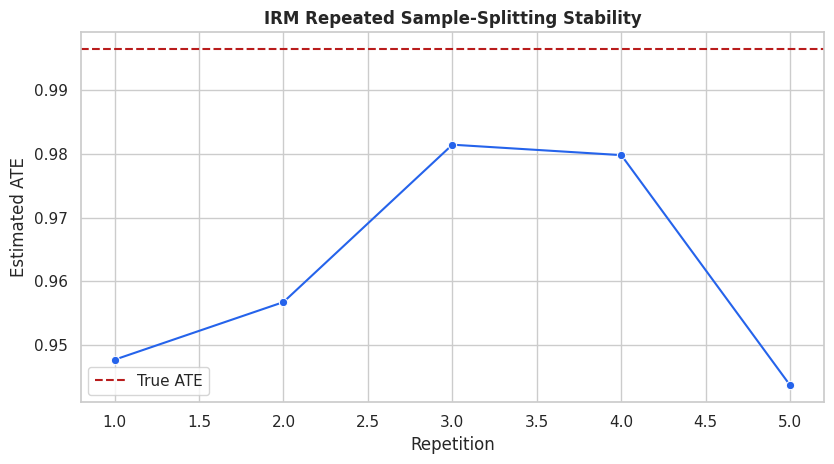

In [28]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.lineplot(data=split_stability, x="repetition", y="theta_hat", marker="o", color="#2563eb", ax=ax)
ax.axhline(TRUE_ATE, color="#b91c1c", linestyle="--", linewidth=1.5, label="True ATE")
ax.set_title("IRM Repeated Sample-Splitting Stability")
ax.set_xlabel("Repetition")
ax.set_ylabel("Estimated ATE")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_repeated_split_stability.png", dpi=160, bbox_inches="tight")
plt.show()

The estimates are stable across split repetitions in this synthetic setting. That supports numerical reliability, not causal identification by itself.

## Overlap Stress Test

Now we isolate the overlap problem. We keep the same potential outcomes but make the treatment assignment rule more or less extreme.

This stress test uses the true nuisance functions so the only thing changing is propensity overlap. As propensities move toward zero or one, weights become more variable and uncertainty increases.

In [29]:
overlap_rows = []
base_logit = true_logit.to_numpy()

for scale in [0.50, 0.85, 1.25, 1.75, 2.50]:
    stress_propensity = np.clip(sigmoid(scale * base_logit), 0.01, 0.99)
    stress_d = rng.binomial(1, stress_propensity, size=N_OBS)
    stress_y = np.where(stress_d == 1, potential_outcome_1, potential_outcome_0)
    stress_aipw = aipw_ate(stress_y, stress_d, true_g0, true_g1, stress_propensity, f"scale={scale}")
    stress_weights = stress_d / stress_propensity + (1 - stress_d) / (1 - stress_propensity)
    overlap_rows.append(
        {
            "logit_scale": scale,
            "treatment_rate": float(stress_d.mean()),
            "propensity_p01": float(np.quantile(stress_propensity, 0.01)),
            "propensity_p99": float(np.quantile(stress_propensity, 0.99)),
            "max_weight": float(np.max(stress_weights)),
            "effective_sample_size": weighted_effective_sample_size(stress_weights),
            "theta_hat_oracle_aipw": stress_aipw["theta_hat"],
            "std_error_oracle_aipw": stress_aipw["std_error"],
            "ci_95_lower": stress_aipw["ci_95_lower"],
            "ci_95_upper": stress_aipw["ci_95_upper"],
        }
    )

overlap_stress = pd.DataFrame(overlap_rows)
overlap_stress["true_ate"] = TRUE_ATE
overlap_stress["bias_vs_true_ate"] = overlap_stress["theta_hat_oracle_aipw"] - TRUE_ATE
save_table(overlap_stress, "overlap_stress_test")
display(overlap_stress)

,logit_scale,treatment_rate,propensity_p01,propensity_p99,max_weight,effective_sample_size,theta_hat_oracle_aipw,std_error_oracle_aipw,ci_95_lower,ci_95_upper,true_ate,bias_vs_true_ate
0,0.50,0.48125,0.218448,0.750508,6.445538,3741.777106,0.975751,0.032919,0.911229,1.040272,0.996435,-0.020684
1,0.85,0.47300,0.102749,0.866718,13.988948,3236.984035,1.020001,0.035749,0.949934,1.090068,0.996435,0.023566
2,1.25,0.46175,0.039664,0.940100,40.438987,2328.986111,0.923440,0.039034,0.846933,0.999947,0.996435,-0.072995
3,1.75,0.45175,0.011412,0.979258,65.500811,1727.041898,1.050359,0.045686,0.960815,1.139902,0.996435,0.053924
4,2.50,0.44900,0.010000,0.990000,100.000000,693.711527,1.004237,0.054236,0.897934,1.110540,0.996435,0.007802


As the treatment rule becomes more extreme, the effective sample size falls and the maximum weight rises. This is the overlap problem in one table.

## Overlap Stress Plot

The left panel shows uncertainty in the oracle AIPW estimate as overlap worsens. The right panel shows the effective sample size implied by inverse-propensity weights.

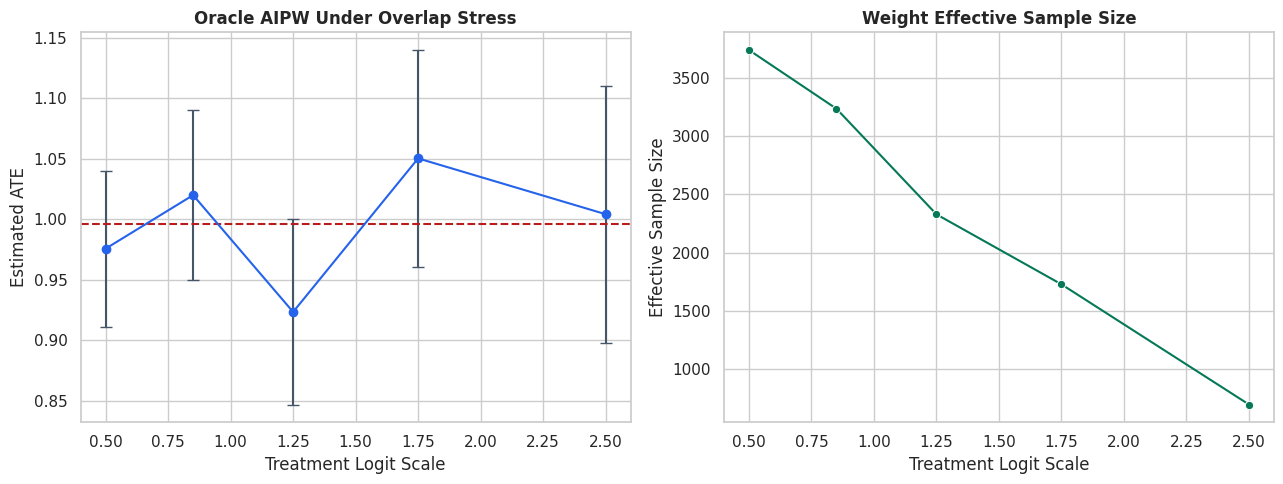

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].errorbar(
    x=overlap_stress["logit_scale"],
    y=overlap_stress["theta_hat_oracle_aipw"],
    yerr=[
        overlap_stress["theta_hat_oracle_aipw"] - overlap_stress["ci_95_lower"],
        overlap_stress["ci_95_upper"] - overlap_stress["theta_hat_oracle_aipw"],
    ],
    fmt="o-",
    color="#2563eb",
    ecolor="#475569",
    capsize=4,
)
axes[0].axhline(TRUE_ATE, color="#b91c1c", linestyle="--", linewidth=1.5)
axes[0].set_title("Oracle AIPW Under Overlap Stress")
axes[0].set_xlabel("Treatment Logit Scale")
axes[0].set_ylabel("Estimated ATE")

sns.lineplot(
    data=overlap_stress,
    x="logit_scale",
    y="effective_sample_size",
    marker="o",
    color="#047857",
    ax=axes[1],
)
axes[1].set_title("Weight Effective Sample Size")
axes[1].set_xlabel("Treatment Logit Scale")
axes[1].set_ylabel("Effective Sample Size")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_overlap_stress_test.png", dpi=160, bbox_inches="tight")
plt.show()

Poor overlap is not solved by a fancier model. It changes the support of the causal question. Sometimes the honest fix is to narrow the target population.

## Propensity Clipping Sensitivity

In practice, analysts often clip or trim extreme propensity scores. Clipping can reduce variance from extreme weights, but it also changes the exact estimating equation.

This cell recomputes manual AIPW estimates under several clipping thresholds.

In [31]:
clipping_rows = []
for clip in [0.01, 0.02, 0.05, 0.10]:
    clipped_m = np.clip(manual_m_hat, clip, 1 - clip)
    ate_row = aipw_ate(y, d, manual_g0_hat, manual_g1_hat, clipped_m, f"AIPW clip={clip:.2f}")
    att_row = aipw_att(y, d, manual_g0_hat, clipped_m, f"ATT-style AIPW clip={clip:.2f}")
    for row in [ate_row, att_row]:
        row["clip_threshold"] = clip
        row["true_target"] = TRUE_ATT if row["target"] == "ATT-style" else TRUE_ATE
        row["bias_vs_target"] = row["theta_hat"] - row["true_target"]
        clipping_rows.append(row)

clipping_sensitivity = pd.DataFrame(clipping_rows)
save_table(clipping_sensitivity, "propensity_clipping_sensitivity")
display(clipping_sensitivity)

,estimator,target,theta_hat,std_error,ci_95_lower,ci_95_upper,p_value,clip_threshold,true_target,bias_vs_target
0,AIPW clip=0.01,ATE,0.961524,0.052736,0.858163,1.064886,NaN,0.01,0.996435,-0.034910
1,ATT-style AIPW clip=0.01,ATT-style,1.116128,0.064518,0.989673,1.242583,NaN,0.01,1.132978,-0.016850
2,AIPW clip=0.02,ATE,0.961524,0.052736,0.858163,1.064886,NaN,0.02,0.996435,-0.034910
3,ATT-style AIPW clip=0.02,ATT-style,1.116128,0.064518,0.989673,1.242583,NaN,0.02,1.132978,-0.016850
4,AIPW clip=0.05,ATE,0.965683,0.051320,0.865096,1.066270,NaN,0.05,0.996435,-0.030752
5,ATT-style AIPW clip=0.05,ATT-style,1.111452,0.063686,0.986628,1.236275,NaN,0.05,1.132978,-0.021527
6,AIPW clip=0.10,ATE,0.964527,0.047148,0.872116,1.056938,NaN,0.10,0.996435,-0.031908
7,ATT-style AIPW clip=0.10,ATT-style,1.105364,0.058841,0.990035,1.220693,NaN,0.10,1.132978,-0.027614


The clipping table is stable here because the propensity distribution is already well behaved. In weaker-overlap data, clipping sensitivity can be much larger.

## When IRM Is The Right Or Wrong Tool

IRM is a good fit when:

- the treatment is binary;
- observed covariates plausibly adjust for treatment assignment;
- there is overlap between treated and untreated units;
- the target is ATE or ATT-style.

IRM is not enough when:

- there is important unobserved confounding;
- the treatment is continuous;
- the treatment is assigned by an instrument or cutoff design;
- overlap is so weak that treated and untreated units are not comparable;
- interference between units is central to the question.

## Reporting Checklist

This checklist turns the notebook into a reusable binary-treatment workflow.

A credible IRM report should include the target estimand, the treatment definition, control timing, propensity overlap, nuisance diagnostics, uncertainty, and limitations.

In [32]:
reporting_checklist = pd.DataFrame(
    [
        {"item": "Causal question", "status": "Estimate effect of feature_exposure on weekly_value."},
        {"item": "Treatment type", "status": "Binary treatment, so IRM is appropriate for ATE and ATTE-style targets."},
        {"item": "Estimands", "status": "Both ATE and ATT-style targets are shown because treatment effects are heterogeneous."},
        {"item": "Control timing", "status": "All controls are pre-treatment by construction in this synthetic dataset."},
        {"item": "Unconfoundedness", "status": "Holds by construction here; requires design evidence in real data."},
        {"item": "Overlap", "status": "Propensity and weight diagnostics reported."},
        {"item": "Nuisance learners", "status": "Compared linear/logistic and gradient-boosted nuisance specifications."},
        {"item": "Cross-fitting", "status": "Manual AIPW and DoubleMLIRM use cross-fitted nuisance predictions."},
        {"item": "Uncertainty", "status": "Standard errors, confidence intervals, and bootstrap intervals reported."},
        {"item": "Stability", "status": "Repeated sample splitting and clipping sensitivity included."},
        {"item": "Main limitation", "status": "IRM does not solve hidden confounding or support violations."},
    ]
)
save_table(reporting_checklist, "irm_reporting_checklist")
display(reporting_checklist)

,item,status
0,Causal question,Estimate effect of feature_exposure on weekly_...
1,Treatment type,"Binary treatment, so IRM is appropriate for AT..."
2,Estimands,Both ATE and ATT-style targets are shown becau...
3,Control timing,All controls are pre-treatment by construction...
4,Unconfoundedness,Holds by construction here; requires design ev...
5,Overlap,Propensity and weight diagnostics reported.
6,Nuisance learners,Compared linear/logistic and gradient-boosted ...
7,Cross-fitting,Manual AIPW and DoubleMLIRM use cross-fitted n...
8,Uncertainty,"Standard errors, confidence intervals, and boo..."
9,Stability,Repeated sample splitting and clipping sensiti...


The checklist forces the analysis to stay causal, not merely predictive. A polished propensity model is not a substitute for a credible assignment story.

## Report Template

The next cell writes a short markdown report template using the main gradient-boosted IRM estimates.

This template is meant to be adapted. In real analyses, the synthetic truth checks would be replaced by design evidence, sensitivity analysis, and robustness checks.

In [33]:
main_ate = irm_summary.loc[irm_summary["estimator"] == "Gradient boosting nuisance IRM ATE"].iloc[0]
main_atte = irm_summary.loc[irm_summary["estimator"] == "Gradient boosting nuisance IRM ATTE"].iloc[0]
ess_value = dml_propensity_diagnostics.loc[
    dml_propensity_diagnostics["diagnostic"] == "IPW effective sample size", "value"
].iloc[0]

report_text = f"""
# IRM Effect Estimate Report Template

## Causal Question
Estimate the effect of `feature_exposure` on `weekly_value` using observed pre-treatment controls.

## Estimands
Two targets are reported:
- ATE: average effect over the full analysis population.
- ATTE: effect for the treated units under the DoubleML treated-target score.

## Main Estimates
ATE estimate:
- Estimated effect: {main_ate['theta_hat']:.4f}
- Standard error: {main_ate['std_error']:.4f}
- 95 percent confidence interval: [{main_ate['ci_95_lower']:.4f}, {main_ate['ci_95_upper']:.4f}]

ATTE estimate:
- Estimated effect: {main_atte['theta_hat']:.4f}
- Standard error: {main_atte['std_error']:.4f}
- 95 percent confidence interval: [{main_atte['ci_95_lower']:.4f}, {main_atte['ci_95_upper']:.4f}]

## Estimator
The main estimator is `DoubleMLIRM` with five-fold cross-fitting, histogram gradient-boosted outcome models, and a histogram gradient-boosted propensity classifier.

## Diagnostics Included
- Difference-in-means, OLS adjustment, manual IPW, manual AIPW, and DoubleML comparisons.
- Propensity overlap and inverse-propensity weight diagnostics.
- Effective sample size from IPW weights: {ess_value:.1f}.
- Outcome nuisance and propensity nuisance quality checks.
- Orthogonal score contribution checks.
- Bootstrap confidence intervals.
- Repeated sample-splitting stability.
- Propensity clipping sensitivity.
- Overlap stress test.

## Required Assumptions
The estimates rely on consistency, conditional unconfoundedness given the selected controls, overlap, and no interference. DoubleML improves estimation under these assumptions but does not establish them.
""".strip()

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_irm_report_template.md"
report_path.write_text(report_text)
print(report_text)

# IRM Effect Estimate Report Template

## Causal Question
Estimate the effect of `feature_exposure` on `weekly_value` using observed pre-treatment controls.

## Estimands
Two targets are reported:
- ATE: average effect over the full analysis population.
- ATTE: effect for the treated units under the DoubleML treated-target score.

## Main Estimates
ATE estimate:
- Estimated effect: 0.9853
- Standard error: 0.0539
- 95 percent confidence interval: [0.8797, 1.0909]

ATTE estimate:
- Estimated effect: 1.0483
- Standard error: 0.0699
- 95 percent confidence interval: [0.9113, 1.1852]

## Estimator
The main estimator is `DoubleMLIRM` with five-fold cross-fitting, histogram gradient-boosted outcome models, and a histogram gradient-boosted propensity classifier.

## Diagnostics Included
- Difference-in-means, OLS adjustment, manual IPW, manual AIPW, and DoubleML comparisons.
- Propensity overlap and inverse-propensity weight diagnostics.
- Effective sample size from IPW weights: 2225.4.
- Out

The report template keeps the estimands, assumptions, overlap diagnostics, and uncertainty attached to the numeric estimates. That is the right shape for binary-treatment causal reporting.

## Artifact Manifest

The final cell lists every artifact produced by this notebook so the outputs are easy to find later.

In [34]:
artifact_rows = []
for folder, artifact_type in [
    (DATASET_DIR, "dataset"),
    (TABLE_DIR, "table"),
    (FIGURE_DIR, "figure"),
    (REPORT_DIR, "report"),
]:
    for file_path in sorted(folder.glob(f"{NOTEBOOK_PREFIX}_*")):
        artifact_rows.append(
            {
                "artifact_type": artifact_type,
                "file_name": file_path.name,
                "relative_path": str(file_path.relative_to(REPO_ROOT)),
            }
        )

artifact_manifest = pd.DataFrame(artifact_rows)
save_table(artifact_manifest, "artifact_manifest")
display(artifact_manifest)

,artifact_type,file_name,relative_path
0,dataset,05_synthetic_irm_data.csv,notebooks/tutorials/doubleml/outputs/datasets/...
1,table,05_all_estimator_comparison.csv,notebooks/tutorials/doubleml/outputs/tables/05...
2,table,05_baseline_estimates.csv,notebooks/tutorials/doubleml/outputs/tables/05...
3,table,05_data_audit.csv,notebooks/tutorials/doubleml/outputs/tables/05...
4,table,05_design_correlation_matrix.csv,notebooks/tutorials/doubleml/outputs/tables/05...
5,table,05_doubleml_irm_summary.csv,notebooks/tutorials/doubleml/outputs/tables/05...
6,table,05_doubleml_nuisance_losses.csv,notebooks/tutorials/doubleml/outputs/tables/05...
7,table,05_doubleml_propensity_diagnostics.csv,notebooks/tutorials/doubleml/outputs/tables/05...
8,table,05_doublemldata_backend_summary.csv,notebooks/tutorials/doubleml/outputs/tables/05...
9,table,05_field_dictionary.csv,notebooks/tutorials/doubleml/outputs/tables/05...


The IRM notebook is complete. The next natural topic is the interactive IV model for binary treatments with instruments and compliance-style reasoning.